In [461]:
#Import Libraries for Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics as sm
import sklearn.linear_model as lm
from sklearn.preprocessing import StandardScaler

In [462]:
#Load Dataset
df=pd.read_csv('/Users/pascalobeng-poku/PyCharmMiscProject/MD_Crime_Data.csv')

In [463]:
#Data Structure/Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1104 entries, 0 to 1103
Data columns (total 38 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   JURISDICTION                                           1104 non-null   object 
 1   YEAR                                                   1104 non-null   int64  
 2   POPULATION                                             1104 non-null   int64  
 3   MURDER                                                 1104 non-null   int64  
 4   RAPE                                                   1104 non-null   int64  
 5   ROBBERY                                                1104 non-null   int64  
 6   AGG. ASSAULT                                           1104 non-null   int64  
 7   B & E                                                  1104 non-null   int64  
 8   LARCENY THEFT                                   

In [464]:
#Sort Values
df=df.sort_values(by= ['JURISDICTION','YEAR'])
df.ffill(inplace=True)

In [465]:
"""
Challenge Questions

Trend Analysis: How have the overall crime rates in Maryland changed from 1975 to 2020? Identify any significant upward or downward trends.

Crime Distribution: What are the most common types of crimes committed in Maryland over the years? How has the distribution of different crime types changed over time?

Geographical Analysis: Which jurisdictions have the highest and lowest crime rates? How do these rates compare to the state average?

Population Correlation: Is there a correlation between population size and crime rates in different jurisdictions? Does a larger population necessarily mean higher crime rates?

Crime Rate Changes: Analyze the rate percent change for different crime types. Which crimes have seen the most significant changes (increases or decreases) over the years?

Crime Hotspots: Identify crime hotspots. Which areas should be prioritized for increased policing and resource allocation?

Bonus: Create a dashboard report for management.

"""

'\nChallenge Questions\n\nTrend Analysis: How have the overall crime rates in Maryland changed from 1975 to 2020? Identify any significant upward or downward trends.\n\nCrime Distribution: What are the most common types of crimes committed in Maryland over the years? How has the distribution of different crime types changed over time?\n\nGeographical Analysis: Which jurisdictions have the highest and lowest crime rates? How do these rates compare to the state average?\n\nPopulation Correlation: Is there a correlation between population size and crime rates in different jurisdictions? Does a larger population necessarily mean higher crime rates?\n\nCrime Rate Changes: Analyze the rate percent change for different crime types. Which crimes have seen the most significant changes (increases or decreases) over the years?\n\nCrime Hotspots: Identify crime hotspots. Which areas should be prioritized for increased policing and resource allocation?\n\nBonus: Create a dashboard report for manage

In [466]:
#Re-checking Data Structure/Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1104 entries, 0 to 1103
Data columns (total 38 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   JURISDICTION                                           1104 non-null   object 
 1   YEAR                                                   1104 non-null   int64  
 2   POPULATION                                             1104 non-null   int64  
 3   MURDER                                                 1104 non-null   int64  
 4   RAPE                                                   1104 non-null   int64  
 5   ROBBERY                                                1104 non-null   int64  
 6   AGG. ASSAULT                                           1104 non-null   int64  
 7   B & E                                                  1104 non-null   int64  
 8   LARCENY THEFT                                        

In [467]:
#Percent Change Calc
df['PERCENT CHANGE CALC']=(df.groupby('JURISDICTION')['GRAND TOTAL'].pct_change()*100)

In [468]:
checks=df[['JURISDICTION', 'YEAR','PERCENT CHANGE CALC', 'PERCENT CHANGE']].head(20)
checks

,JURISDICTION,YEAR,PERCENT CHANGE CALC,PERCENT CHANGE
0,Allegany County,1975,NaN,NaN
1,Allegany County,1976,-8.759124,-8.8
2,Allegany County,1977,4.047059,4.0
3,Allegany County,1978,-3.618272,-3.6
4,Allegany County,1979,8.962928,9.0
5,Allegany County,1980,6.546081,6.5
6,Allegany County,1981,-0.040420,0.0
7,Allegany County,1982,-11.484027,-11.5
8,Allegany County,1983,-11.009593,-11.0
9,Allegany County,1984,-4.671458,-4.7


In [469]:
#Find Errors
df['DIFFERENCE']=df['PERCENT CHANGE']-df['PERCENT CHANGE CALC']
df[df['DIFFERENCE'].abs()>0.01]

,JURISDICTION,YEAR,POPULATION,MURDER,RAPE,ROBBERY,AGG. ASSAULT,B & E,LARCENY THEFT,M/V THEFT,...,"M/V THEFT PER 100,000 PEOPLE","MURDER RATE PERCENT CHANGE PER 100,000 PEOPLE","RAPE RATE PERCENT CHANGE PER 100,000 PEOPLE","ROBBERY RATE PERCENT CHANGE PER 100,000 PEOPLE","AGG. ASSAULT RATE PERCENT CHANGE PER 100,000 PEOPLE","B & E RATE PERCENT CHANGE PER 100,000 PEOPLE","LARCENY THEFT RATE PERCENT CHANGE PER 100,000 PEOPLE","M/V THEFT RATE PERCENT CHANGE PER 100,000 PEOPLE",PERCENT CHANGE CALC,DIFFERENCE
1,Allegany County,1976,83923,2,2,24,59,581,1384,73,...,87.0,-36.7,-62.0,13.9,-50.9,-17.6,-7.8,-25.5,-8.759124,-0.040876
2,Allegany County,1977,82102,3,7,32,85,592,1390,102,...,124.2,53.3,257.8,36.3,47.3,4.2,2.7,42.8,4.047059,-0.047059
3,Allegany County,1978,79966,1,2,18,81,539,1390,100,...,125.1,-65.8,-70.7,-42.2,-2.2,-6.5,2.7,0.7,-3.618272,0.018272
4,Allegany County,1979,79721,1,7,18,84,502,1611,99,...,124.2,0.3,251.1,0.3,4.0,-6.6,16.3,-0.7,8.962928,0.037072
5,Allegany County,1980,80461,2,12,26,79,541,1706,108,...,134.2,98.2,69.9,43.1,-6.8,6.8,4.9,8.1,6.546081,-0.046081
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1099,Worcester County,2016,51255,3,17,39,93,289,1514,32,...,62.4,201.8,14.0,45.3,-8.3,6.5,-2.5,15.0,-1.045817,0.045817
1100,Worcester County,2017,51408,2,26,43,106,220,1514,39,...,75.9,-33.5,52.5,9.9,13.6,-24.1,-0.3,21.5,-1.862104,-0.037896
1101,Worcester County,2018,51304,0,12,24,88,215,1178,34,...,66.3,-100.0,-53.8,-44.1,-16.8,-2.1,-22.0,-12.6,-20.461538,-0.038462
1102,Worcester County,2019,51606,0,12,24,94,186,1086,30,...,58.1,0.0,-0.6,-0.6,6.2,-14.0,-8.3,-12.3,-7.672469,-0.027531


In [470]:
#Number of Errors
errors=df[df['DIFFERENCE'].abs()>0.01]
print(errors[['PERCENT CHANGE CALC', 'PERCENT CHANGE','YEAR','JURISDICTION']])
print(len(errors[['PERCENT CHANGE CALC', 'PERCENT CHANGE','YEAR','JURISDICTION']]))

      PERCENT CHANGE CALC  PERCENT CHANGE  YEAR      JURISDICTION
1               -8.759124            -8.8  1976   Allegany County
2                4.047059             4.0  1977   Allegany County
3               -3.618272            -3.6  1978   Allegany County
4                8.962928             9.0  1979   Allegany County
5                6.546081             6.5  1980   Allegany County
...                   ...             ...   ...               ...
1099            -1.045817            -1.0  2016  Worcester County
1100            -1.862104            -1.9  2017  Worcester County
1101           -20.461538           -20.5  2018  Worcester County
1102            -7.672469            -7.7  2019  Worcester County
1103             7.262570             7.3  2020  Worcester County

[857 rows x 4 columns]
857


In [471]:
#Fix Column
df['PERCENT CHANGE']=df['PERCENT CHANGE CALC']

In [472]:
#Transforming Columns
df.columns=(df.columns.str.replace(' ', '_').str.replace('&','AND').str.replace('/','_'))
df.columns

Index(['JURISDICTION', 'YEAR', 'POPULATION', 'MURDER', 'RAPE', 'ROBBERY',
       'AGG._ASSAULT', 'B_AND_E', 'LARCENY_THEFT', 'M_V_THEFT', 'GRAND_TOTAL',
       'PERCENT_CHANGE', 'VIOLENT_CRIME_TOTAL', 'VIOLENT_CRIME_PERCENT',
       'VIOLENT_CRIME_PERCENT_CHANGE', 'PROPERTY_CRIME_TOTALS',
       'PROPERTY_CRIME_PERCENT', 'PROPERTY_CRIME_PERCENT_CHANGE',
       'OVERALL_CRIME_RATE_PER_100,000_PEOPLE',
       'OVERALL_PERCENT_CHANGE_PER_100,000_PEOPLE',
       'VIOLENT_CRIME_RATE_PER_100,000_PEOPLE',
       'VIOLENT_CRIME_RATE_PERCENT_CHANGE_PER_100,000_PEOPLE',
       'PROPERTY_CRIME_RATE_PER_100,000_PEOPLE',
       'PROPERTY_CRIME_RATE_PERCENT_CHANGE_PER_100,000_PEOPLE',
       'MURDER_PER_100,000_PEOPLE', 'RAPE_PER_100,000_PEOPLE',
       'ROBBERY_PER_100,000_PEOPLE', 'AGG._ASSAULT_PER_100,000_PEOPLE',
       'B_AND_E_PER_100,000_PEOPLE', 'LARCENY_THEFT_PER_100,000_PEOPLE',
       'M_V_THEFT_PER_100,000_PEOPLE',
       'MURDER__RATE_PERCENT_CHANGE_PER_100,000_PEOPLE',
       'RAPE_RAT

In [473]:
#Statistical Data
df.describe()

,YEAR,POPULATION,MURDER,RAPE,ROBBERY,AGG._ASSAULT,B_AND_E,LARCENY_THEFT,M_V_THEFT,GRAND_TOTAL,...,"M_V_THEFT_PER_100,000_PEOPLE","MURDER__RATE_PERCENT_CHANGE_PER_100,000_PEOPLE","RAPE_RATE_PERCENT_CHANGE_PER_100,000_PEOPLE","ROBBERY_RATE_PERCENT_CHANGE_PER_100,000_PEOPLE","AGG._ASSAULT__RATE_PERCENT_CHANGE_PER_100,000_PEOPLE","B_AND_E_RATE_PERCENT_CHANGE_PER_100,000_PEOPLE","LARCENY_THEFT__RATE_PERCENT_CHANGE_PER_100,000_PEOPLE","M_V_THEFT__RATE_PERCENT_CHANGE_PER_100,000_PEOPLE",PERCENT_CHANGE_CALC,DIFFERENCE
count,1104.000000,1.104000e+03,1104.000000,1104.000000,1104.000000,1104.000000,1104.000000,1104.000000,1104.000000,1104.000000,...,1104.000000,1103.000000,1103.000000,1103.000000,1103.000000,1103.000000,1103.000000,1103.00000,1080.000000,1080.000000
mean,1997.500000,2.135711e+05,19.792572,67.255435,584.390399,836.451087,1866.405797,5559.250000,1000.884058,9934.429348,...,242.910870,58.416772,20.471079,9.347235,2.508069,-2.913781,-1.553672,1.83971,-0.460929,0.052411
std,13.281935,2.679479e+05,56.119445,117.103181,1605.213379,1576.662620,3219.535754,8597.885293,2315.062532,16810.954485,...,282.408568,204.677485,135.413114,74.767725,25.618170,16.014872,11.315555,30.06964,9.785152,2.047515
min,1975.000000,1.620000e+04,0.000000,0.000000,0.000000,11.000000,32.000000,91.000000,2.000000,152.000000,...,10.500000,-100.000000,-100.000000,-100.000000,-80.400000,-45.700000,-37.800000,-74.30000,-29.495380,-10.872014
25%,1986.000000,3.304875e+04,1.000000,9.000000,17.000000,108.000000,256.000000,679.750000,43.000000,1115.750000,...,97.700000,-40.600000,-18.600000,-18.600000,-11.300000,-13.000000,-8.000000,-15.15000,-6.593217,-0.023372
50%,1997.500000,9.007450e+04,3.000000,21.000000,48.000000,257.500000,609.500000,1813.000000,125.500000,2840.000000,...,143.700000,0.000000,0.200000,-1.800000,-0.500000,-3.300000,-1.900000,-1.50000,-0.524531,0.001762
75%,2009.000000,2.375618e+05,7.000000,46.000000,186.250000,545.500000,1230.000000,3766.250000,413.250000,6042.500000,...,269.150000,68.800000,25.650000,16.750000,12.400000,5.250000,4.700000,13.15000,5.273745,0.025039
max,2020.000000,1.062595e+06,353.000000,754.000000,12408.000000,10536.000000,18604.000000,46750.000000,18482.000000,96243.000000,...,2184.100000,2066.900000,2937.100000,1320.000000,194.400000,81.300000,81.000000,225.20000,41.995842,66.388372


In [474]:
#Data Preview
df.head(10)

,JURISDICTION,YEAR,POPULATION,MURDER,RAPE,ROBBERY,AGG._ASSAULT,B_AND_E,LARCENY_THEFT,M_V_THEFT,...,"M_V_THEFT_PER_100,000_PEOPLE","MURDER__RATE_PERCENT_CHANGE_PER_100,000_PEOPLE","RAPE_RATE_PERCENT_CHANGE_PER_100,000_PEOPLE","ROBBERY_RATE_PERCENT_CHANGE_PER_100,000_PEOPLE","AGG._ASSAULT__RATE_PERCENT_CHANGE_PER_100,000_PEOPLE","B_AND_E_RATE_PERCENT_CHANGE_PER_100,000_PEOPLE","LARCENY_THEFT__RATE_PERCENT_CHANGE_PER_100,000_PEOPLE","M_V_THEFT__RATE_PERCENT_CHANGE_PER_100,000_PEOPLE",PERCENT_CHANGE_CALC,DIFFERENCE
0,Allegany County,1975,79655,3,5,20,114,669,1425,93,...,116.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Allegany County,1976,83923,2,2,24,59,581,1384,73,...,87.0,-36.7,-62.0,13.9,-50.9,-17.6,-7.8,-25.5,-8.759124,-0.040876
2,Allegany County,1977,82102,3,7,32,85,592,1390,102,...,124.2,53.3,257.8,36.3,47.3,4.2,2.7,42.8,4.047059,-0.047059
3,Allegany County,1978,79966,1,2,18,81,539,1390,100,...,125.1,-65.8,-70.7,-42.2,-2.2,-6.5,2.7,0.7,-3.618272,0.018272
4,Allegany County,1979,79721,1,7,18,84,502,1611,99,...,124.2,0.3,251.1,0.3,4.0,-6.6,16.3,-0.7,8.962928,0.037072
5,Allegany County,1980,80461,2,12,26,79,541,1706,108,...,134.2,98.2,69.9,43.1,-6.8,6.8,4.9,8.1,6.546081,-0.046081
6,Allegany County,1981,81781,11,13,24,101,539,1697,88,...,107.6,441.1,6.6,-9.2,25.8,-2.0,-2.1,-19.8,-0.040420,0.040420
7,Allegany County,1982,81858,1,18,18,80,447,1570,55,...,67.2,-90.9,38.3,-25.1,-20.9,-17.1,-7.6,-37.6,-11.484027,-0.015973
8,Allegany County,1983,82605,5,9,19,89,347,1412,67,...,81.1,395.5,-50.5,4.6,10.2,-23.1,-10.9,20.7,-11.009593,0.009593
9,Allegany County,1984,80835,2,15,6,67,361,1338,68,...,84.1,-59.1,70.3,-67.7,-23.1,6.3,-3.2,3.7,-4.671458,-0.028542


In [475]:
#Shape of Data
df.shape

(1104, 40)

In [476]:
#Duplicate values
df.duplicated().sum()

#There are no duplicate values

np.int64(0)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following fa

<function matplotlib.pyplot.show(close=None, block=None)>

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following fa

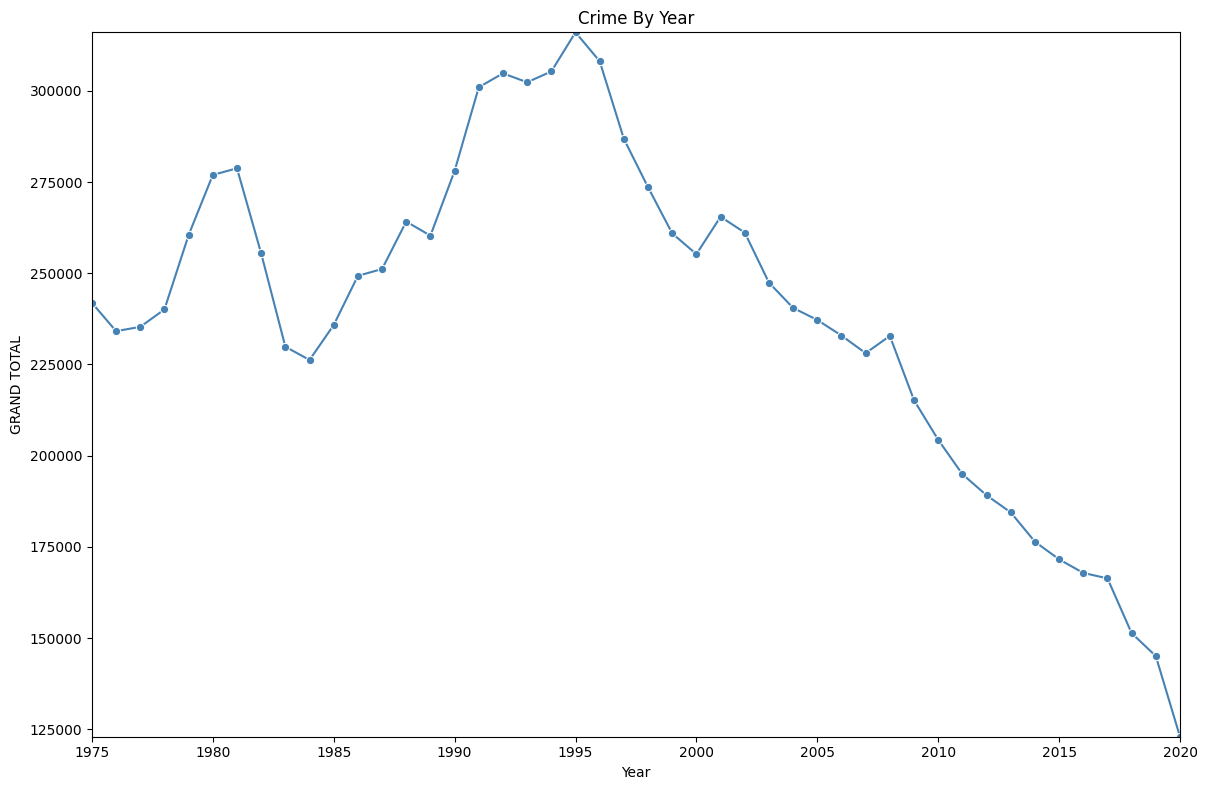

In [477]:
#Total Crime by Year
crime_by_year = df.groupby('YEAR')['GRAND_TOTAL'].sum().sort_values(ascending=False)
crime_by_year

plt.figure(figsize=(12,8), dpi=100, facecolor='w', edgecolor='k')
sns.lineplot(crime_by_year, marker= 'o', color= 'steelblue')
plt.title('Crime By Year')
plt.xlabel('Year')
plt.ylabel('GRAND TOTAL')
plt.tight_layout()
plt.autoscale(tight=True)
plt.show

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following fa

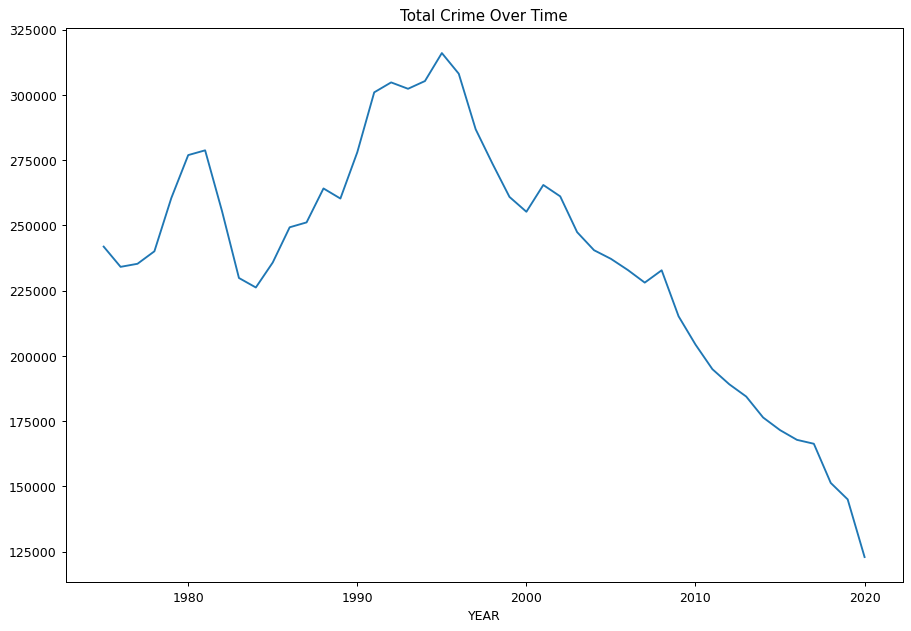

In [478]:
#Total Crime Over Time
df.groupby("YEAR")["GRAND_TOTAL"].sum().plot()
plt.title("Total Crime Over Time")
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following fa

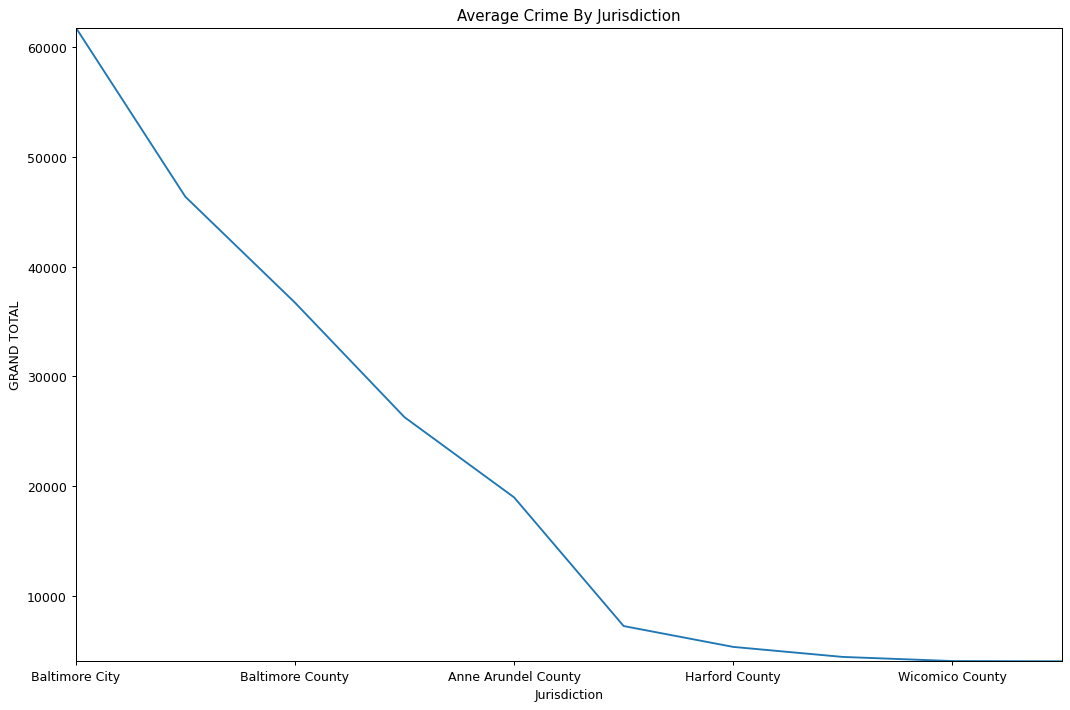

<Figure size 1200x800 with 0 Axes>

In [479]:
#Average Crime by Jurisdiction
average_crime_by_jurisdiction = df.groupby('JURISDICTION')['GRAND_TOTAL'].mean().sort_values(ascending=False).head(10).plot()

plt.title('Average Crime By Jurisdiction')
plt.xlabel('Jurisdiction')
plt.ylabel('GRAND TOTAL')
plt.tight_layout()
plt.autoscale(tight=True)
plt.figure(figsize=(12,8), dpi=100, facecolor='w', edgecolor='k')
plt.show()

plt.rcParams['figure.figsize'] = (12,8)
plt.rcParams['figure.dpi'] = 90
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False


In [480]:
#Crime by Jurisdiction
crime_by_jurisdiction = df.groupby('JURISDICTION')['GRAND_TOTAL'].sum().sort_values(ascending=False).head(10)
crime_by_jurisdiction

JURISDICTION
Baltimore City            2842811
Prince George's County    2132933
Baltimore County          1688857
Montgomery County         1208032
Anne Arundel County        871803
Howard County              331924
Harford County             244447
Frederick County           202392
Wicomico County            185137
Charles County             184292
Name: GRAND_TOTAL, dtype: int64

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following fa

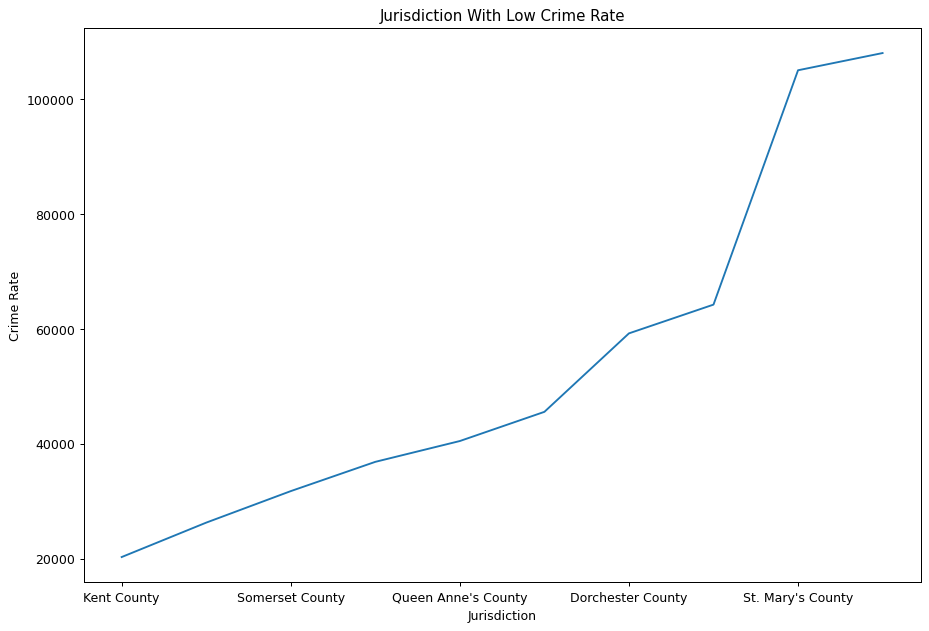

In [481]:
#Crime by Jurisdiction
crime_by_jurisdiction = df.groupby('JURISDICTION')['GRAND_TOTAL'].sum().sort_values(ascending=True).head(10).plot()
plt.title('Jurisdiction With Low Crime Rate')
plt.xlabel('Jurisdiction')
plt.ylabel('Crime Rate')
plt.show()

In [482]:
#Crime Rate in Maryland
crime_rate=(df['GRAND_TOTAL']/df['POPULATION']).sum()*100
crime_rate

np.float64(4072.1468209900763)

In [483]:
#Crime Rate
df['CRIME_RATE']=df['GRAND_TOTAL']/df['POPULATION']
df['CRIME_RATE'].head(20)

0     0.029239
1     0.025321
2     0.026930
3     0.026649
4     0.029127
5     0.030748
6     0.030239
7     0.026741
8     0.023582
9     0.022973
10    0.023115
11    0.025409
12    0.026566
13    0.027856
14    0.029853
15    0.031863
16    0.032412
17    0.034982
18    0.032641
19    0.032072
Name: CRIME_RATE, dtype: float64

In [484]:
#Violent Ratio
df['VIOLENT_RATIO']= df['VIOLENT_CRIME_TOTAL']/df['GRAND_TOTAL']
df['VIOLENT_RATIO'].head(20)

0     0.060970
1     0.040941
2     0.057440
3     0.047865
4     0.047373
5     0.048100
6     0.060251
7     0.053449
8     0.062628
9     0.048465
10    0.049582
11    0.060319
12    0.076082
13    0.076490
14    0.083772
15    0.099665
16    0.128797
17    0.134522
18    0.154660
19    0.137634
Name: VIOLENT_RATIO, dtype: float64

/var/folders/n_/1jz470q16xj_x2hjq_48vmrw0000gn/T/ipykernel_50846/2244366785.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(df.head(500), x= 'YEAR', y='VIOLENT_RATIO', palette= 'deep')
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the followi

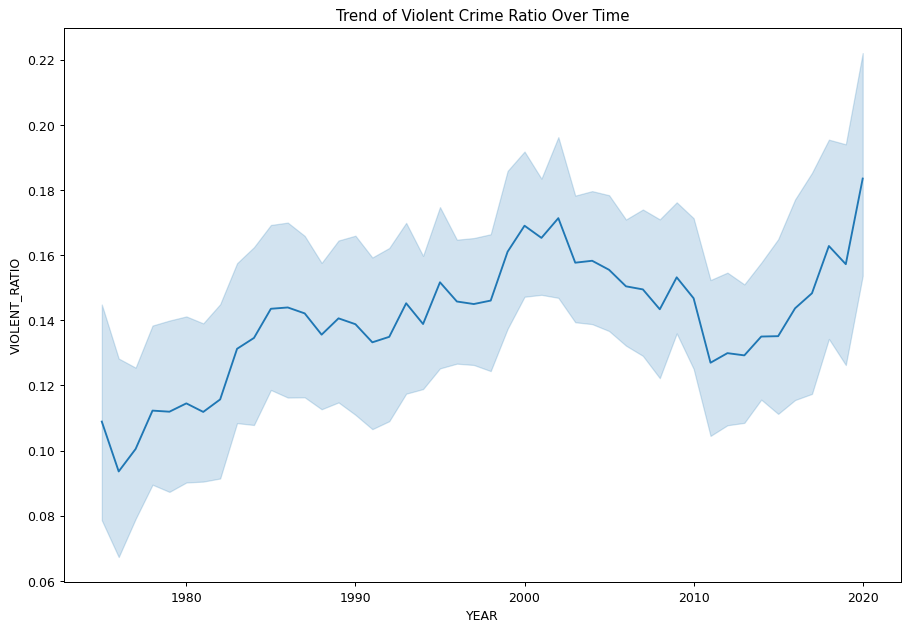

In [485]:
#Violent Crime Trend
sns.lineplot(df.head(500), x= 'YEAR', y='VIOLENT_RATIO', palette= 'deep')
plt.title('Trend of Violent Crime Ratio Over Time')
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following fa

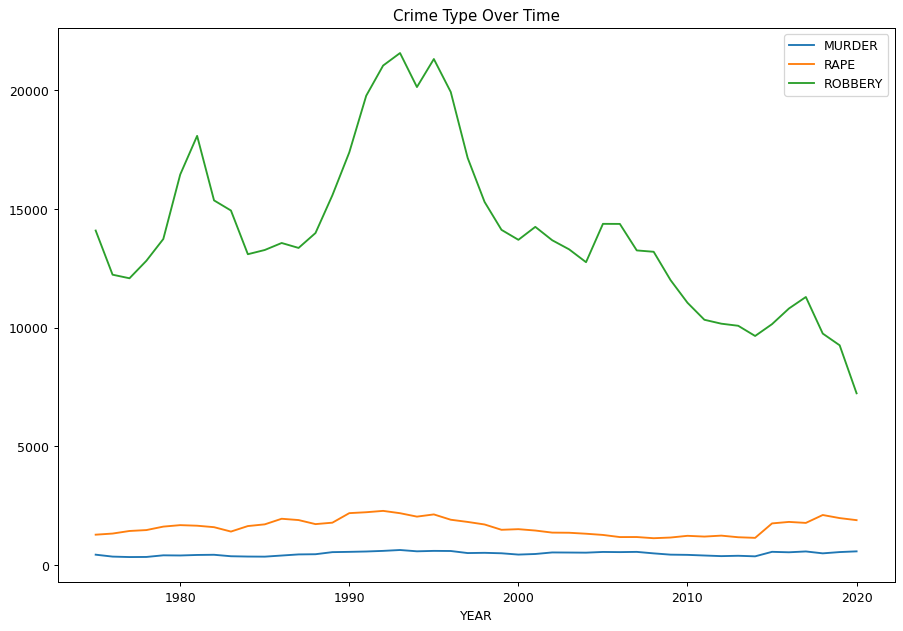

In [486]:
#Crime types over time
df.groupby('YEAR')[['MURDER','RAPE', 'ROBBERY']].sum().plot()
plt.title('Crime Type Over Time')
plt.show()

In [487]:
#All Columns
df.columns

Index(['JURISDICTION', 'YEAR', 'POPULATION', 'MURDER', 'RAPE', 'ROBBERY',
       'AGG._ASSAULT', 'B_AND_E', 'LARCENY_THEFT', 'M_V_THEFT', 'GRAND_TOTAL',
       'PERCENT_CHANGE', 'VIOLENT_CRIME_TOTAL', 'VIOLENT_CRIME_PERCENT',
       'VIOLENT_CRIME_PERCENT_CHANGE', 'PROPERTY_CRIME_TOTALS',
       'PROPERTY_CRIME_PERCENT', 'PROPERTY_CRIME_PERCENT_CHANGE',
       'OVERALL_CRIME_RATE_PER_100,000_PEOPLE',
       'OVERALL_PERCENT_CHANGE_PER_100,000_PEOPLE',
       'VIOLENT_CRIME_RATE_PER_100,000_PEOPLE',
       'VIOLENT_CRIME_RATE_PERCENT_CHANGE_PER_100,000_PEOPLE',
       'PROPERTY_CRIME_RATE_PER_100,000_PEOPLE',
       'PROPERTY_CRIME_RATE_PERCENT_CHANGE_PER_100,000_PEOPLE',
       'MURDER_PER_100,000_PEOPLE', 'RAPE_PER_100,000_PEOPLE',
       'ROBBERY_PER_100,000_PEOPLE', 'AGG._ASSAULT_PER_100,000_PEOPLE',
       'B_AND_E_PER_100,000_PEOPLE', 'LARCENY_THEFT_PER_100,000_PEOPLE',
       'M_V_THEFT_PER_100,000_PEOPLE',
       'MURDER__RATE_PERCENT_CHANGE_PER_100,000_PEOPLE',
       'RAPE_RAT

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following fa

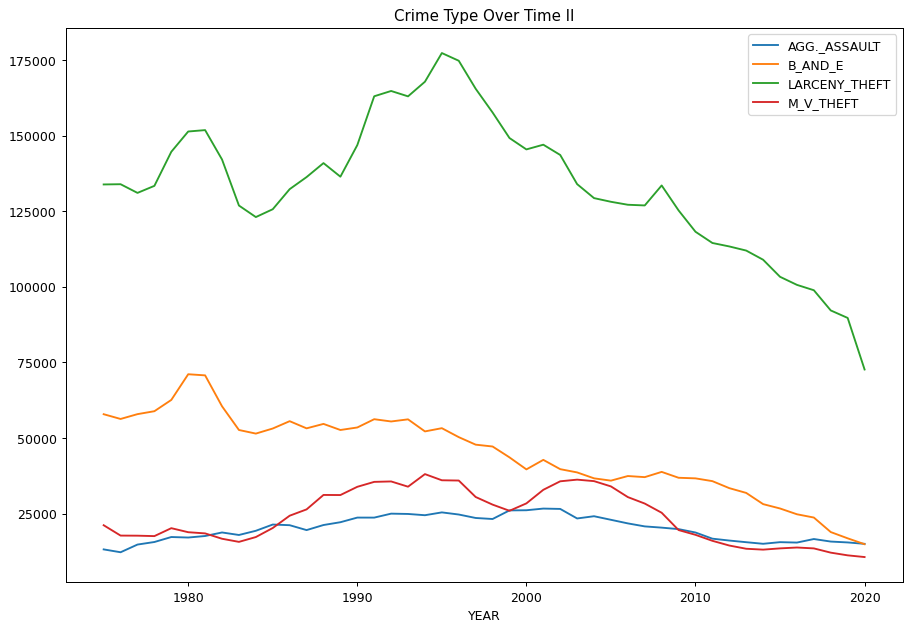

In [488]:
#Crime types over time II
df.groupby('YEAR')[['AGG._ASSAULT','B_AND_E','LARCENY_THEFT','M_V_THEFT']].sum().plot()
plt.title('Crime Type Over Time II')
plt.show()

In [489]:
#Top 10 Dangerous Jurisdictions
top_10 = df.groupby('JURISDICTION')['GRAND_TOTAL'].mean().sort_values(ascending=False).head(10)
top_10

JURISDICTION
Baltimore City            61800.239130
Prince George's County    46368.108696
Baltimore County          36714.282609
Montgomery County         26261.565217
Anne Arundel County       18952.239130
Howard County              7215.739130
Harford County             5314.065217
Frederick County           4399.826087
Wicomico County            4024.717391
Charles County             4006.347826
Name: GRAND_TOTAL, dtype: float64

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following fa

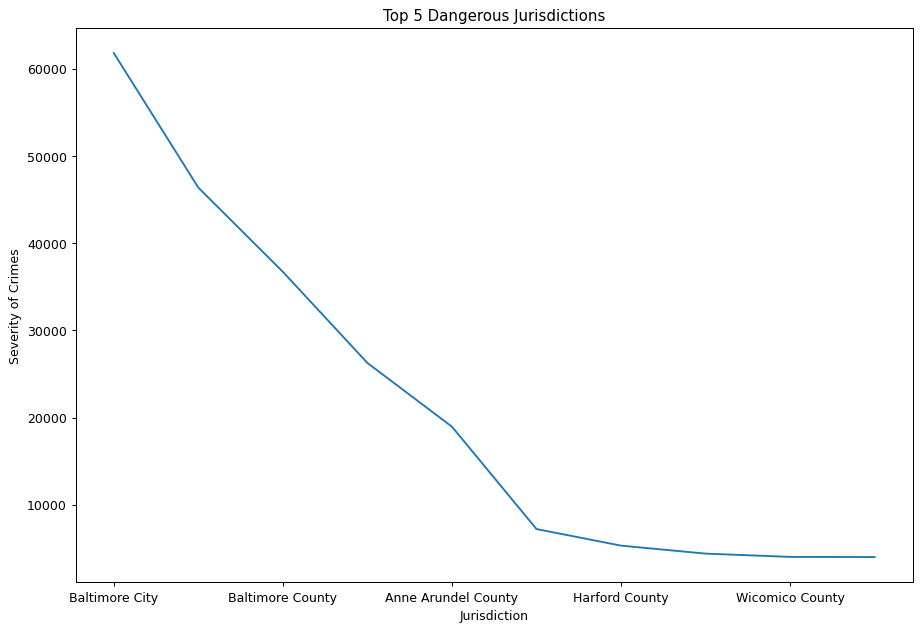

In [490]:
#Top 10 Dangerous Jurisdictions Visualization
top_10.plot()
plt.title('Top 5 Dangerous Jurisdictions')
plt.ylabel('Severity of Crimes')
plt.xlabel('Jurisdiction')
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following fa

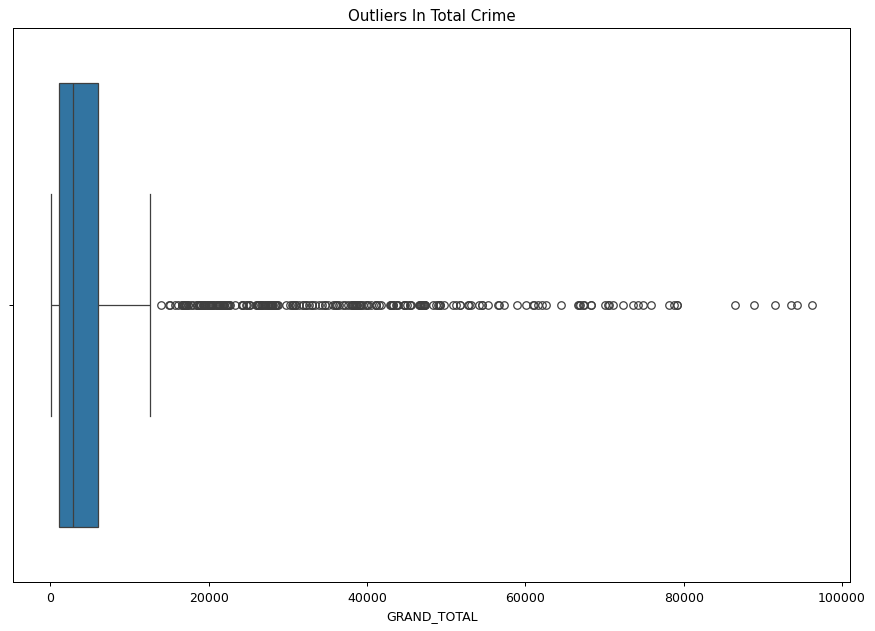

In [491]:
#Outlier Detection
sns.boxplot(x=df['GRAND_TOTAL'])
plt.title('Outliers In Total Crime')
plt.show()

In [492]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1104 entries, 0 to 1103
Data columns (total 42 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   JURISDICTION                                           1104 non-null   object 
 1   YEAR                                                   1104 non-null   int64  
 2   POPULATION                                             1104 non-null   int64  
 3   MURDER                                                 1104 non-null   int64  
 4   RAPE                                                   1104 non-null   int64  
 5   ROBBERY                                                1104 non-null   int64  
 6   AGG._ASSAULT                                           1104 non-null   int64  
 7   B_AND_E                                                1104 non-null   int64  
 8   LARCENY_THEFT                                        

In [493]:
#Columns of all Crime Types
crime_columns= [
    'MURDER','RAPE','ROBBERY', 'AGG._ASSAULT', 'B_AND_E', 'LARCENY_THEFT', 'M_V_THEFT'
]

In [494]:
#Sort all Crime Types
total_by_type = df[crime_columns].sum().sort_values(ascending=False)
print('Total Incidents by Crime Type:')
total_by_type

Total Incidents by Crime Type:


LARCENY_THEFT    6137412
B_AND_E          2060512
M_V_THEFT        1104976
AGG._ASSAULT      923442
ROBBERY           645167
RAPE               74250
MURDER             21851
dtype: int64

/var/folders/n_/1jz470q16xj_x2hjq_48vmrw0000gn/T/ipykernel_50846/1042061399.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_by_type.values, y=total_by_type.index, palette='deep')
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following famil

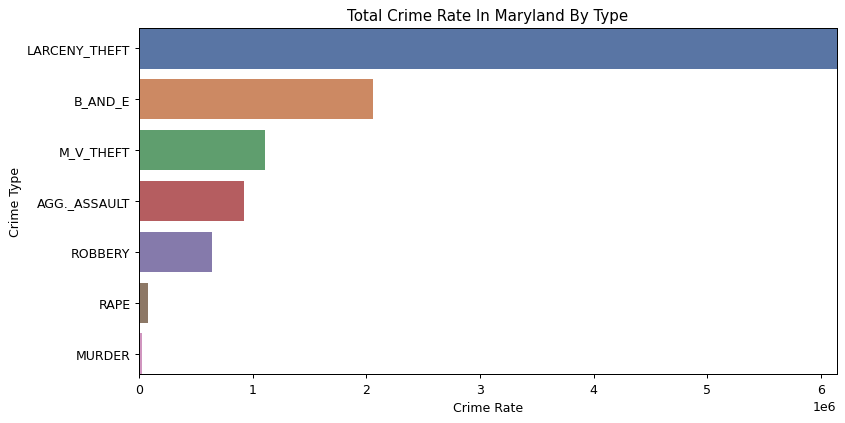

In [495]:
#Plot a bar chart of totals
plt.figure(figsize=(10,5))
sns.barplot(x=total_by_type.values, y=total_by_type.index, palette='deep')
plt.title('Total Crime Rate In Maryland By Type')
plt.autoscale(tight=True)
plt.xlabel('Crime Rate')
plt.ylabel('Crime Type')
plt.show()

In [496]:
#Reshape the data so we have Crime Type column and Count column
df_long=df.melt(id_vars='YEAR', value_vars=crime_columns, var_name='Crime Type', value_name='Count' )


In [497]:
#Group by year and type
yearly_trends= df_long.groupby(['YEAR','Crime Type'])['Count'].sum().reset_index()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following fa

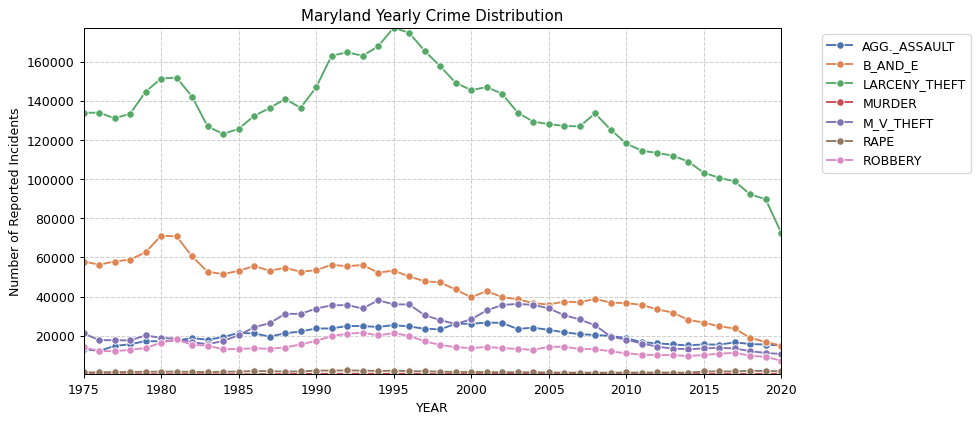

In [498]:
#Plot a Line graph for change over the years

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_trends,x= 'YEAR', y='Count', hue='Crime Type', marker='o', palette='deep')
plt.autoscale(tight=True)
plt.title('Maryland Yearly Crime Distribution')
plt.ylabel('Number of Reported Incidents')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Correlation(Population Verses Total Volume):'0.85
Correlation (Population Verses Crime Rate):'0.40


findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following fa

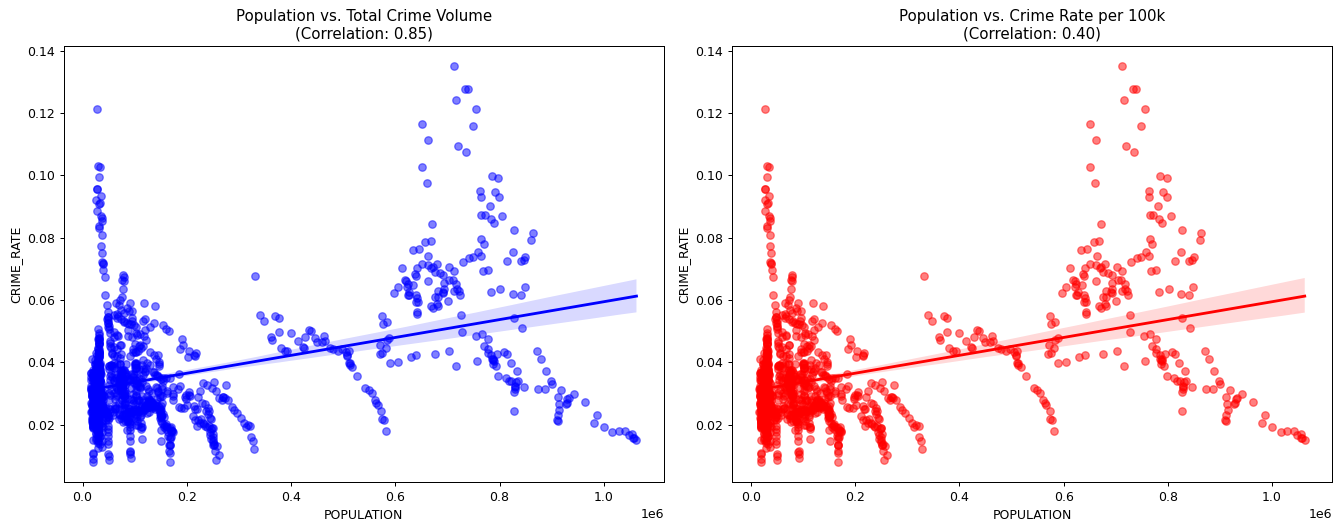

In [499]:
#Numeric Correlation Co-efficients
corr_volume= df['POPULATION'].corr(df['GRAND_TOTAL'])
corr_rate= df['POPULATION'].corr(df['CRIME_RATE'])

print(f"Correlation(Population Verses Total Volume):'{corr_volume:.2f}")
print(f"Correlation (Population Verses Crime Rate):'{corr_rate:.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.regplot(data=df, x='POPULATION', y='CRIME_RATE', ax=ax1, color='blue', scatter_kws={'alpha':0.5})
ax1.set_title(f'Population vs. Total Crime Volume\n(Correlation: {corr_volume:.2f})')

# Plot B: Population vs Crime Rate (Normalized)
sns.regplot(data=df, x='POPULATION', y='CRIME_RATE', ax=ax2, color='red', scatter_kws={'alpha':0.5})
ax2.set_title(f'Population vs. Crime Rate per 100k\n(Correlation: {corr_rate:.2f})')

plt.tight_layout()
plt.show()

/var/folders/n_/1jz470q16xj_x2hjq_48vmrw0000gn/T/ipykernel_50846/595139571.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_changes.values, y=avg_changes.index, palette='RdYlGn_r')
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following famil

Average Annual Percent Change by Crime Type:
B_AND_E_RATE_PERCENT_CHANGE_PER_100,000_PEOPLE            -2.913781
M_V_THEFT__RATE_PERCENT_CHANGE_PER_100,000_PEOPLE          1.839710
AGG._ASSAULT__RATE_PERCENT_CHANGE_PER_100,000_PEOPLE       2.508069
ROBBERY_RATE_PERCENT_CHANGE_PER_100,000_PEOPLE             9.347235
RAPE_RATE_PERCENT_CHANGE_PER_100,000_PEOPLE               20.471079
MURDER__RATE_PERCENT_CHANGE_PER_100,000_PEOPLE            58.416772
LARCENY_THEFT_PER_100,000_PEOPLE                        2169.928714
dtype: float64


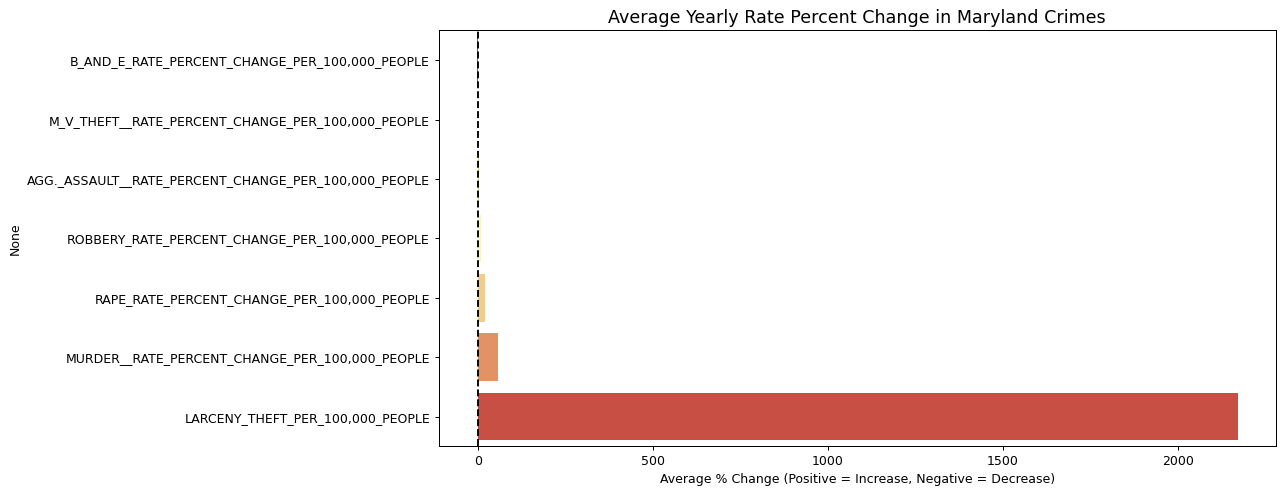

In [500]:
# Define the rate change columns from your dataset info
change_cols = [
    'MURDER__RATE_PERCENT_CHANGE_PER_100,000_PEOPLE',
    'RAPE_RATE_PERCENT_CHANGE_PER_100,000_PEOPLE',
    'ROBBERY_RATE_PERCENT_CHANGE_PER_100,000_PEOPLE',
    'AGG._ASSAULT__RATE_PERCENT_CHANGE_PER_100,000_PEOPLE',
    'B_AND_E_RATE_PERCENT_CHANGE_PER_100,000_PEOPLE',
    'LARCENY_THEFT_PER_100,000_PEOPLE',
    'M_V_THEFT__RATE_PERCENT_CHANGE_PER_100,000_PEOPLE'
]

#Calculate the Average and Absolute Change
# Absolute will help identify "volatility" (crimes that swing wildly up or down)
avg_changes = df[change_cols].mean().sort_values()
volatility = df[change_cols].abs().mean().sort_values(ascending=False)

print("Average Annual Percent Change by Crime Type:")
print(avg_changes)

# Visualize the Average Percent Change
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_changes.values, y=avg_changes.index, palette='RdYlGn_r')
plt.axvline(0, color='black', linestyle='--')
plt.title('Average Yearly Rate Percent Change in Maryland Crimes', fontsize=14)
plt.xlabel('Average % Change (Positive = Increase, Negative = Decrease)')
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following fa

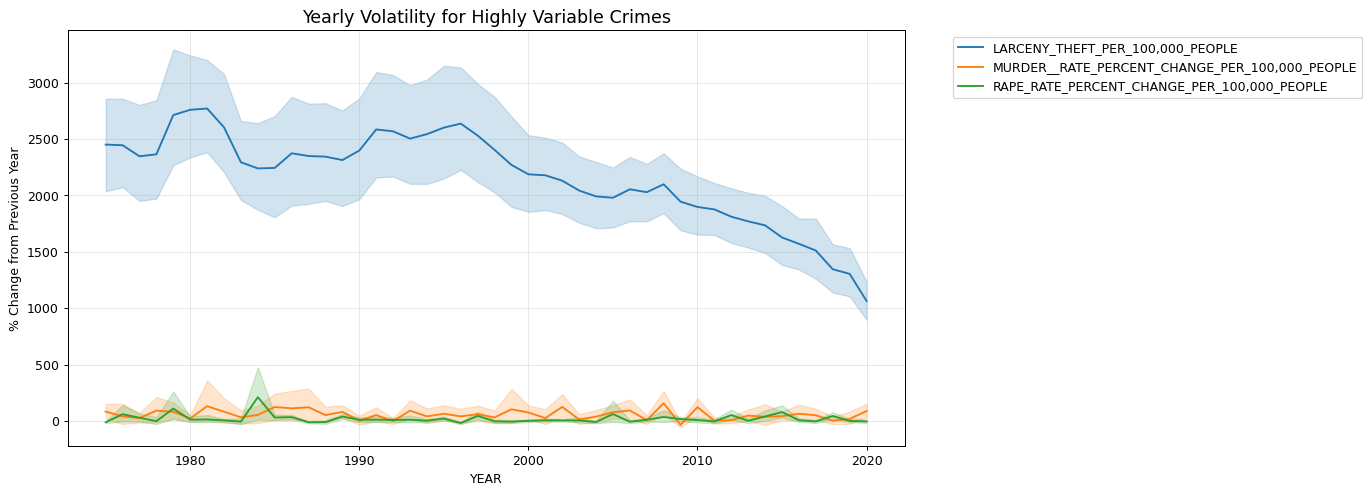

In [501]:
#Detailed Trend Plot for Top 3 Most Volatile Crimes
top_volatile = volatility.head(3).index.tolist()
plt.figure(figsize=(12, 6))
for col in top_volatile:
    sns.lineplot(data=df, x='YEAR', y=col, label=col.split(' ')[0])

plt.title('Yearly Volatility for Highly Variable Crimes', fontsize=14)
plt.ylabel('% Change from Previous Year')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [502]:
df.groupby(['CRIME_RATE'])['JURISDICTION'].sum().sort_values(ascending=False).unique()

array(['Worcester County', 'Wicomico County', 'Washington County',
       'Talbot County', "St. Mary's County", 'Somerset County',
       "Queen Anne's County", "Prince George's County",
       'Montgomery County', 'Kent County', 'Howard County',
       'Harford County', 'Garrett County', 'Frederick County',
       'Dorchester County', 'Charles County', 'Cecil County',
       'Carroll County', 'Caroline County', 'Calvert County',
       'Baltimore County', 'Baltimore City', 'Anne Arundel County',
       'Allegany County'], dtype=object)

In [503]:
#The most recent year in your dataset to get current hotspots
latest_year = df['YEAR'].max()
current_df = df[df['YEAR'] == latest_year]

#Hotspots by Volume (Where the most crimes happen in total)
# High priority for large-scale resource allocation
volume_hotspots = current_df.nlargest(5, 'GRAND_TOTAL')[['JURISDICTION', 'GRAND_TOTAL', 'POPULATION']]

#Hotspots by Rate (Where it is most 'dangerous' per person)
# High priority for targeted policing and social programs
rate_hotspots = current_df.nlargest(5, 'OVERALL_CRIME_RATE_PER_100,000_PEOPLE')[['JURISDICTION', 'OVERALL_CRIME_RATE_PER_100,000_PEOPLE']]

print(f"--- Top 5 Hotspots by Total Volume ({latest_year}) ---")
print(volume_hotspots)

print(f"\n--- Top 5 Hotspots by Crime Rate per 100k ({latest_year}) ---")
print(rate_hotspots)

--- Top 5 Hotspots by Total Volume (2020) ---
               JURISDICTION  GRAND_TOTAL  POPULATION
137          Baltimore City        28147      588594
183        Baltimore County        20045      826987
781  Prince George's County        19401      911234
735       Montgomery County        16594     1055918
91      Anne Arundel County        10433      581937

--- Top 5 Hotspots by Crime Rate per 100k (2020) ---
           JURISDICTION  OVERALL_CRIME_RATE_PER_100,000_PEOPLE
137      Baltimore City                                 4782.1
459   Dorchester County                                 3093.7
1103   Worcester County                                 2943.0
183    Baltimore County                                 2423.9
43      Allegany County                                 2193.7


In [504]:
df.to_csv('Maryland Crime Data_Cleaned.csv', index=False)